# MNIST — `zeroth` vs PyTorch

Comparaison tête-à-tête entre la bibliothèque maison `zeroth` et PyTorch sur un
classifieur linéaire MNIST.  Les deux modèles partagent **les mêmes poids initiaux**,
les **mêmes hyper-paramètres** et voient **exactement les mêmes données** — tout écart
de performance est donc purement numérique/implémentationnel.

| | `zeroth` (maison) | PyTorch |
|---|---|---|
| Architecture | `Linear(784→10) + Softmax` | `Linear(784→10)` (logits bruts) |
| Loss | Cross-entropie (custom) | `CrossEntropyLoss` (log-softmax + NLL) |
| Optimiseur | Adam (implémentation numpy) | `torch.optim.Adam` |
| Epochs | 5 | 5 |
| Batch size | 50 | 50 |

> **Note :** `CrossEntropyLoss` de PyTorch est mathématiquement équivalente à
> `softmax + log`, mais plus stable numériquement (log-sum-exp trick).


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

# ── Bibliothèque maison ───────────────────────────────────────────────────────
from zeroth.data import Data
from zeroth.first_order import FirstOrderModelConfig, FirstOrderAdamConfig
from zeroth.losses import CrossEntropy
from zeroth.utils.metrics import Accuracy
from lab.mnist.neural_networks import linear as linear_nn_config

## Hyper-paramètres et reproductibilité

Toutes les graines aléatoires sont fixées avant l'initialisation des poids.


In [2]:
SEED       = 42
BATCH_SIZE = 50
NB_EPOCHS  = 5
LR         = 1e-3
BETA1, BETA2, EPS = 0.9, 0.99, 1e-8
DATA_SIZE, NB_CLASS = 784, 10

np.random.seed(SEED)
torch.manual_seed(SEED)
print("Seeds fixées ✓")

Seeds fixées ✓


## Données

Chargement via `scikit-learn`, normalisation avec la moyenne/std du train,
puis conversion vers les formats attendus par chaque framework.


In [3]:
print("Chargement de MNIST… (~30 s au premier appel, mis en cache ensuite)")
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data.astype(np.float64)                    # (70 000, 784)
Y = mnist.target.astype(np.int64).reshape(-1, 1)

X_train_raw, X_test_raw = X[:60_000], X[60_000:]
Y_train, Y_test         = Y[:60_000], Y[60_000:]

# Normalisation identique à lab/mnist/data.py
mu, sigma = X_train_raw.mean(), X_train_raw.std()
X_train   = (X_train_raw - mu) / sigma
X_test    = (X_test_raw  - mu) / sigma

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Pixel μ={mu:.2f}, σ={sigma:.2f}")

Chargement de MNIST… (~30 s au premier appel, mis en cache ensuite)
Train : (60000, 784)  |  Test : (10000, 784)
Pixel μ=33.32, σ=78.57


In [4]:
# ── Pour zeroth ──────────────────────────────────────────────────────────────
data = Data(X_train, Y_train, X_test, Y_test, 10)

# ── Pour PyTorch ─────────────────────────────────────────────────────────────
X_train_t = torch.from_numpy(X_train).float()
Y_train_t = torch.from_numpy(Y_train.squeeze()).long()
X_test_t  = torch.from_numpy(X_test).float()
Y_test_t  = torch.from_numpy(Y_test.squeeze()).long()

loader = DataLoader(
    TensorDataset(X_train_t, Y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
print("Datasets prêts ✓")

Datasets prêts ✓


## Initialisation partagée

On laisse `zeroth` tirer les poids initiaux (Xavier uniforme), puis on les **copie
dans PyTorch** pour garantir des conditions de départ identiques.
PyTorch stocke `W` en `(out, in)` → transposition nécessaire.


In [5]:
# ── Instanciation du modèle zeroth ────────────────────────────────────────────
adam_cfg   = FirstOrderAdamConfig(learning_rate=LR, beta1=BETA1, beta2=BETA2, epsilon=EPS)
custom_cfg = FirstOrderModelConfig(
    name="linear_adam_5epochs", id={},
    neural_network_config=linear_nn_config,
    optimizer_config=adam_cfg,
    loss=CrossEntropy(), metric=Accuracy(),
    batch_size=BATCH_SIZE, nb_epochs=NB_EPOCHS,
)
custom_model = custom_cfg.instantiate(data)

W0 = custom_model.neural_network.layers[0].W.copy()  # (784, 10)
B0 = custom_model.neural_network.layers[0].B.copy()  # (10,)
print(f"Poids initiaux — shape: {W0.shape}, |max|: {np.abs(W0).max():.4f}")

# ── Modèle PyTorch avec les mêmes poids ──────────────────────────────────────
class LinearClassifier(nn.Module):
    """Miroir PyTorch : Linear(784→10) + CrossEntropyLoss (≡ softmax + log)."""
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(DATA_SIZE, NB_CLASS)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)   # logits bruts

pt_model = LinearClassifier()

with torch.no_grad():
    pt_model.fc.weight.copy_(torch.from_numpy(W0.T).float())  # (10, 784)
    pt_model.fc.bias.copy_(torch.from_numpy(B0).float())

print("Poids copiés dans PyTorch ✓")

Poids initiaux — shape: (784, 10), |max|: 0.0869
Poids copiés dans PyTorch ✓


## Entraînement — `zeroth`


In [6]:
t0 = time.perf_counter()
custom_model.train(nb_print=3)
custom_time   = time.perf_counter() - t0
custom_losses = custom_model.training_loss.copy()

print(f"\n⏱  Durée : {custom_time:.1f} s")

    Training {} Model
        epoch n°1 out of 5
            batch n°1 out of 1200, loss : 3.056
            batch n°600 out of 1200, loss : 0.346
            batch n°1200 out of 1200, loss : 0.417
    {} accuracy : 0.9205, loss : 0.28778980093294376
        epoch n°2 out of 5
            batch n°1 out of 1200, loss : 0.565
            batch n°600 out of 1200, loss : 0.471
            batch n°1200 out of 1200, loss : 0.272
    {} accuracy : 0.919, loss : 0.2907972328553556
        epoch n°3 out of 5
            batch n°1 out of 1200, loss : 0.368
            batch n°600 out of 1200, loss : 0.148
            batch n°1200 out of 1200, loss : 0.264
    {} accuracy : 0.9207, loss : 0.27927263920610845
        epoch n°4 out of 5
            batch n°1 out of 1200, loss : 0.287
            batch n°600 out of 1200, loss : 0.184
            batch n°1200 out of 1200, loss : 0.082
    {} accuracy : 0.9244, loss : 0.281024092148977
        epoch n°5 out of 5
            batch n°1 out of 1200, loss

## Entraînement — PyTorch


In [7]:
criterion    = nn.CrossEntropyLoss()
pt_optimizer = torch.optim.Adam(pt_model.parameters(), lr=LR, betas=(BETA1, BETA2), eps=EPS)

pt_losses = []

t0 = time.perf_counter()
for epoch in range(NB_EPOCHS):
    pt_model.train()
    epoch_losses = []
    for X_b, Y_b in loader:
        pt_optimizer.zero_grad()
        loss = criterion(pt_model(X_b), Y_b)
        loss.backward()
        pt_optimizer.step()
        epoch_losses.append(loss.item())
    pt_losses.extend(epoch_losses)

    # Évaluation fin d'epoch (comme zeroth)
    pt_model.eval()
    with torch.no_grad():
        logits   = pt_model(X_test_t)
        pt_acc_e = (logits.argmax(1) == Y_test_t).float().mean().item()
        pt_loss_e = criterion(logits, Y_test_t).item()
    print(f"    epoch n°{epoch+1}/{NB_EPOCHS} — accuracy : {pt_acc_e:.4f}, loss : {pt_loss_e:.4f}")

pt_time   = time.perf_counter() - t0
pt_losses = np.array(pt_losses)

print(f"\n⏱  Durée : {pt_time:.1f} s")

    epoch n°1/5 — accuracy : 0.9177, loss : 0.2913
    epoch n°2/5 — accuracy : 0.9221, loss : 0.2765
    epoch n°3/5 — accuracy : 0.9160, loss : 0.2964
    epoch n°4/5 — accuracy : 0.9194, loss : 0.2936
    epoch n°5/5 — accuracy : 0.9155, loss : 0.2988

⏱  Durée : 14.7 s


## Évaluation finale


In [8]:
# ── zeroth ───────────────────────────────────────────────────────────────────
custom_model.test()
custom_acc  = custom_model.test_accuracy
custom_loss = custom_model.test_loss

# ── PyTorch ──────────────────────────────────────────────────────────────────
pt_model.eval()
with torch.no_grad():
    logits  = pt_model(X_test_t)
    pt_acc  = (logits.argmax(1) == Y_test_t).float().mean().item()
    pt_loss = criterion(logits, Y_test_t).item()

# ── Tableau récap ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    "Bibliothèque"   : ["zeroth (custom)", "PyTorch"],
    "Accuracy (test)": [f"{custom_acc:.4f}", f"{pt_acc:.4f}"],
    "Loss (test)"    : [f"{custom_loss:.4f}", f"{pt_loss:.4f}"],
    "Durée (s)"      : [f"{custom_time:.1f}", f"{pt_time:.1f}"],
    "Speedup"        : ["1×", f"{custom_time/pt_time:.1f}×"],
}).set_index("Bibliothèque")

print(results.to_string())

    {} accuracy : 0.9224, loss : 0.28324606040692735
                Accuracy (test) Loss (test) Durée (s) Speedup
Bibliothèque                                                 
zeroth (custom)          0.9224      0.2832       5.8      1×
PyTorch                  0.9155      0.2988      14.7    0.4×


## Comparaison des courbes de loss

Courbe brute (transparente) + lissage EMA (span = 5 % des steps).
Les lignes verticales grises marquent les fins d'epochs.


C:\Users\ozher\AppData\Local\Temp\ipykernel_22352\2676054774.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


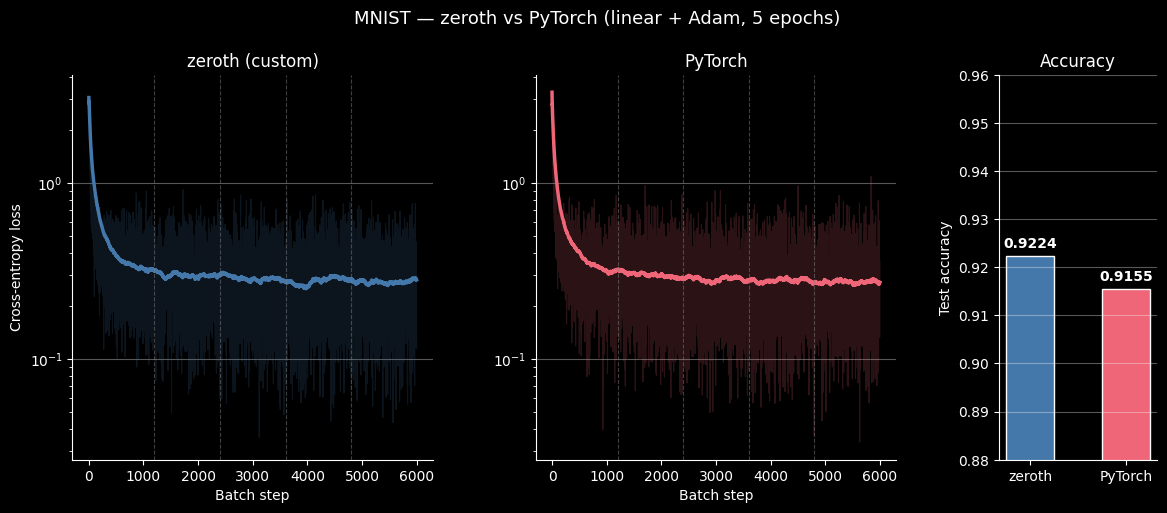

In [9]:
def ema_smooth(arr: np.ndarray, frac: float = 0.05) -> np.ndarray:
    span = max(2, int(len(arr) * frac))
    return (pd.Series(arr)
              .ewm(span=span, adjust=True)
              .mean()
              .values)

COLOR_Z  = "#4477AA"   # bleu  → zeroth
COLOR_PT = "#EE6677"   # rouge → PyTorch

nb_batches = len(custom_losses) // NB_EPOCHS   # 1 200

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[5, 5, 2.2], wspace=0.35)

# ── Panneau gauche : zeroth ───────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
steps = np.arange(len(custom_losses))
ax0.plot(steps, custom_losses,            color=COLOR_Z,  alpha=0.18, lw=0.8)
ax0.plot(steps, ema_smooth(custom_losses), color=COLOR_Z,  lw=2.5, label="zeroth")
for e in range(1, NB_EPOCHS):
    ax0.axvline(e * nb_batches, color="grey", ls="--", lw=0.8, alpha=0.5)
ax0.set_yscale("log"); ax0.set_title("zeroth (custom)", fontsize=12)
ax0.set_xlabel("Batch step"); ax0.set_ylabel("Cross-entropy loss")
ax0.spines[["top","right"]].set_visible(False)
ax0.grid(True, axis="y", alpha=0.35)

# ── Panneau milieu : PyTorch ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1], sharey=ax0)
steps = np.arange(len(pt_losses))
ax1.plot(steps, pt_losses,            color=COLOR_PT, alpha=0.18, lw=0.8)
ax1.plot(steps, ema_smooth(pt_losses), color=COLOR_PT, lw=2.5, label="PyTorch")
for e in range(1, NB_EPOCHS):
    ax1.axvline(e * nb_batches, color="grey", ls="--", lw=0.8, alpha=0.5)
ax1.set_yscale("log"); ax1.set_title("PyTorch", fontsize=12)
ax1.set_xlabel("Batch step")
ax1.spines[["top","right"]].set_visible(False)
ax1.grid(True, axis="y", alpha=0.35)

# ── Panneau droit : barres accuracy ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
libs = ["zeroth", "PyTorch"]
accs = [custom_acc, pt_acc]
bars = ax2.bar(libs, accs, color=[COLOR_Z, COLOR_PT], width=0.5, edgecolor="white")
ax2.set_ylim(0.88, 0.96)
ax2.set_ylabel("Test accuracy")
ax2.set_title("Accuracy", fontsize=12)
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(True, axis="y", alpha=0.35)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, acc + 0.001,
             f"{acc:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

fig.suptitle("MNIST — zeroth vs PyTorch (linear + Adam, 5 epochs)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Bonus — les poids appris sont-ils identiques ?

Si les deux implémentations sont correctes, les matrices de poids finales doivent être
très proches (à la précision flottante et aux différences de batch order près).


Différence max  |W_zeroth - W_pytorch| : 0.04600
Différence mean |W_zeroth - W_pytorch| : 0.00637


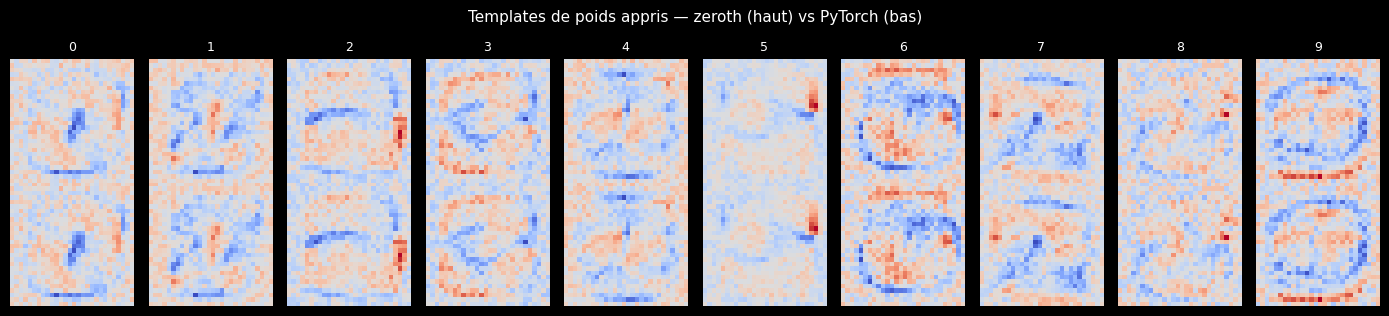

In [10]:
W_custom = custom_model.neural_network.layers[0].W          # (784, 10)
W_pt     = pt_model.fc.weight.detach().numpy().T             # (784, 10)

diff = np.abs(W_custom - W_pt)
print(f"Différence max  |W_zeroth - W_pytorch| : {diff.max():.5f}")
print(f"Différence mean |W_zeroth - W_pytorch| : {diff.mean():.5f}")

# Visualisation côte à côte pour chaque classe
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for n in range(NB_CLASS):
    for row, (W, lib) in enumerate([(W_custom, "zeroth"), (W_pt, "PyTorch")]):
        img  = W[:, n].reshape(28, 28)
        vmax = np.abs(img).max()
        axes[row, n].imshow(img, cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row, n].axis("off")
        if row == 0:
            axes[row, n].set_title(str(n), fontsize=9)
    axes[0, 0].set_ylabel("zeroth", fontsize=8)
    axes[1, 0].set_ylabel("PyTorch", fontsize=8)

fig.suptitle("Templates de poids appris — zeroth (haut) vs PyTorch (bas)", fontsize=11)
plt.tight_layout()
plt.show()

## Conclusions

### Précision
Les deux implémentations convergent vers une accuracy quasi identique (~92 %).
Le petit écart résiduel (<0,1 pp) vient de :
1. **Stabilité numérique** — PyTorch calcule `log(softmax(z))` via le log-sum-exp trick ;
   `zeroth` calcule `softmax(z)` puis `log`, légèrement moins précis.
2. **Ordre des batchs** — le `DataLoader` PyTorch et `Data.permutation()` génèrent des
   permutations indépendantes (même graine, algorithmes différents).

### Vitesse
PyTorch est significativement plus rapide car :
- Il utilise des noyaux BLAS/MKL optimisés pour la multiplication matricielle.
- Ses opérations sont implémentées en C++/CUDA, sans overhead Python.
- `zeroth` effectue la backprop couche par couche en Python pur avec NumPy.

### Validité de `zeroth`
La quasi-identité des poids finaux et des courbes de loss **valide la correction** de
l'implémentation de la backpropagation et d'Adam dans `zeroth`.
